In [1]:
import sys
sys.path.append('../../simulations/csf_sims/work_package_1')

import single_crystal_analysis
from single_crystal_analysis.imports import *
from surrogatetools import *
import arviz as az
import sklearn

from matplotlib.lines import Line2D

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'

# 1. Import and load simulation and experimental data

Large batches - 600 sims

In [2]:
# Fixed tau_0 - 5 params, 500 sims
dislotwin_111_params_file = './data/dislotwin/train_111/dislotwin_single_crystal_lhs_50k_time_steps_low_rho_5_params_600_sims_2026-06-18_113005_parameters_from_zero_strain.npy'
dislotwin_111_outputs_file = './data/dislotwin/train_111/dislotwin_single_crystal_lhs_50k_time_steps_low_rho_5_params_600_sims_2026-06-18_113005_outputs_from_zero_strain.npy'

dislotwin_001_params_file = './data/dislotwin/train_001/dislotwin_single_crystal_lhs_001_50k_time_steps_low_rho_5_params_600_sims_2026-06-18_112615_parameters_from_zero_strain.npy'
dislotwin_001_outputs_file = './data/dislotwin/train_001/dislotwin_single_crystal_lhs_001_50k_time_steps_low_rho_5_params_600_sims_2026-06-18_112615_outputs_from_zero_strain.npy'

Import test data - 125 sims

In [3]:
test_dislo_111_params = np.load('./data/dislotwin/test_111/dislotwin_single_crystal_lhs_50k_time_steps_low_rho_5_params_test_125_sims_2026-06-19_163014_parameters_from_zero_strain.npy')
test_dislo_111_outputs = np.load('./data/dislotwin/test_111/dislotwin_single_crystal_lhs_50k_time_steps_low_rho_5_params_test_125_sims_2026-06-19_163014_outputs_from_zero_strain.npy')

test_dislo_001_params = np.load('./data/dislotwin/test_001/dislotwin_single_crystal_lhs_001_50k_time_steps_low_rho_5_params_test_125_sims_2026-06-19_163121_parameters_from_zero_strain.npy')
test_dislo_001_outputs = np.load('./data/dislotwin/test_001/dislotwin_single_crystal_lhs_001_50k_time_steps_low_rho_5_params_test_125_sims_2026-06-19_163121_outputs_from_zero_strain.npy')

Import experimental data

In [4]:
# Load in experimental data for [111] loading from Takeuchi
exp_111_data_file = '/Users/user/Documents/extracted_data/single_crystal_copper_tensile_tests/takeuchi_111_copper_exp_elongation.csv'
exp_111_true_strain, exp_111_true_stress = single_crystal_analysis.load_exp_data(exp_111_data_file, true_data=False)

# Load in experimental data for [001] loading from Takeuchi
exp_001_data_file = '/Users/user/Documents/extracted_data/single_crystal_copper_tensile_tests/takeuchi_001_copper_exp_elongation.csv'
exp_001_true_strain, exp_001_true_stress = single_crystal_analysis.load_exp_data(exp_001_data_file, true_data=False)

In [5]:
dislotwin_111_params, dislotwin_111_outputs = single_crystal_analysis.load_LHS_outputs(dislotwin_111_outputs_file, dislotwin_111_params_file, filter = False)
dislotwin_001_params, dislotwin_001_outputs = single_crystal_analysis.load_LHS_outputs(dislotwin_001_outputs_file, dislotwin_001_params_file, filter = False)

In [6]:
#Specify strain increments
strain_incs = np.linspace(0.000,0.135,100)

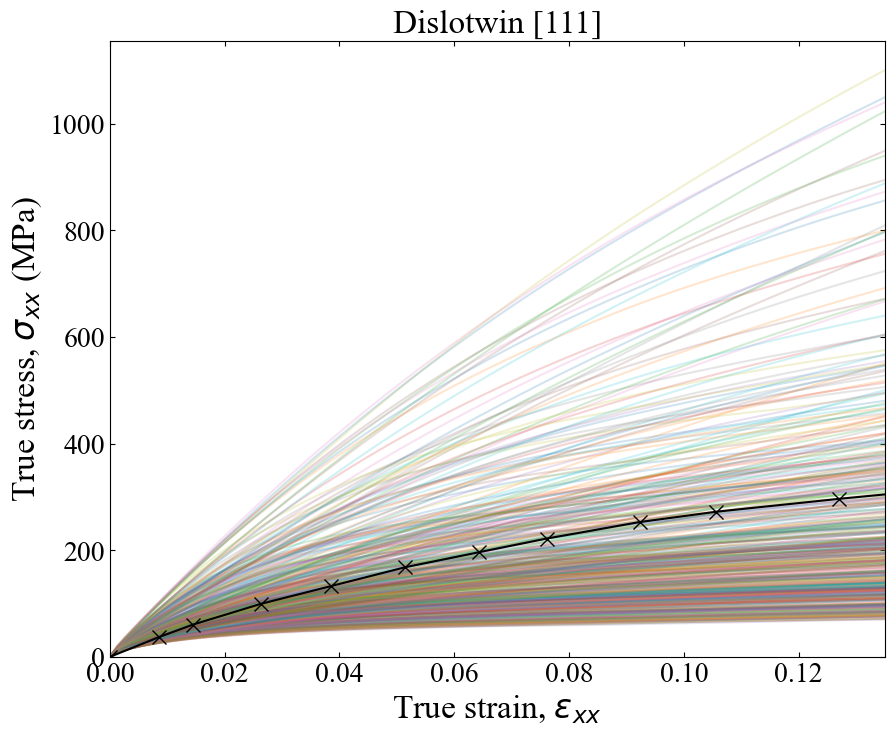

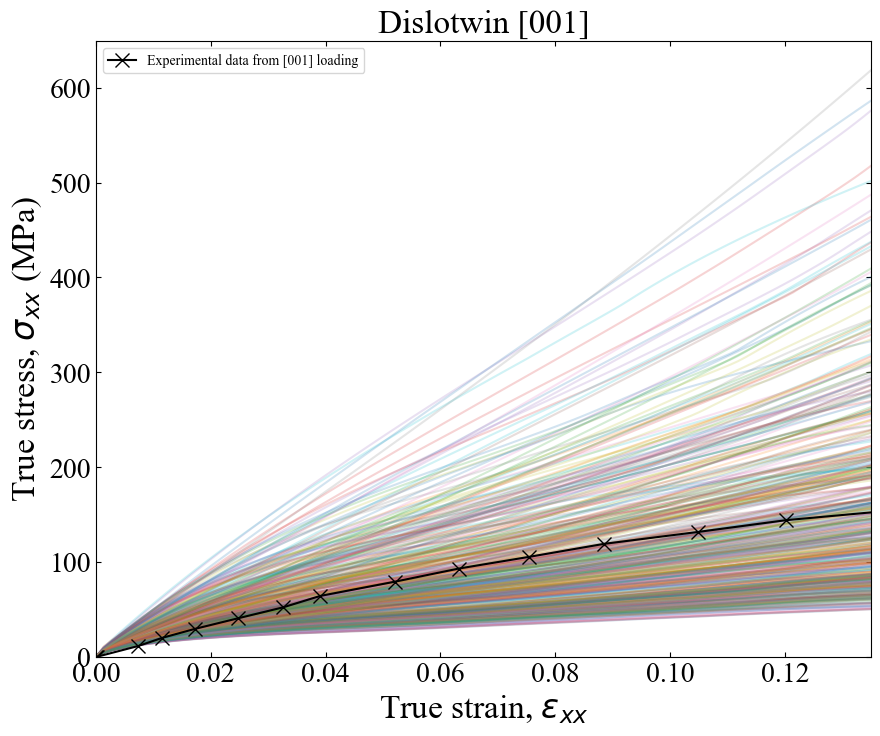

In [7]:
#Plot stress-strain curves from training data and reference curve
%matplotlib inline
single_crystal_analysis.plot_LHS_sample_stress_strain_curves(strain_incs, dislotwin_111_outputs, model_type = 'Dislotwin [111]')
plt.plot(exp_111_true_strain, exp_111_true_stress, 'k', linestyle = '-', marker = 'x', markersize = 10, label = 'Experimental data from [111] loading')
plt.ylim(0)
plt.xlim(0)
single_crystal_analysis.plot_LHS_sample_stress_strain_curves(strain_incs, dislotwin_001_outputs, model_type = 'Dislotwin [001]')
plt.plot(exp_001_true_strain, exp_001_true_stress, 'k', linestyle = '-', marker = 'x', markersize = 10,  label = 'Experimental data from [001] loading')
plt.ylim(0)
plt.xlim(0)
plt.legend(loc = 'upper left')

In [8]:
dislo_fitting_param_names = [r'$\text{log}_{10}(\rho_{0}[\text{m}^{-2}])$', r'$\it{p}$', r'$\it{q}$', r'$\it{i}_{\it{s}}$', r'$\it{D}_{\it{a}}$']

Training distributions

Text(0.5, 0.98, 'Training Data Distributions - Dislotwin [111]')

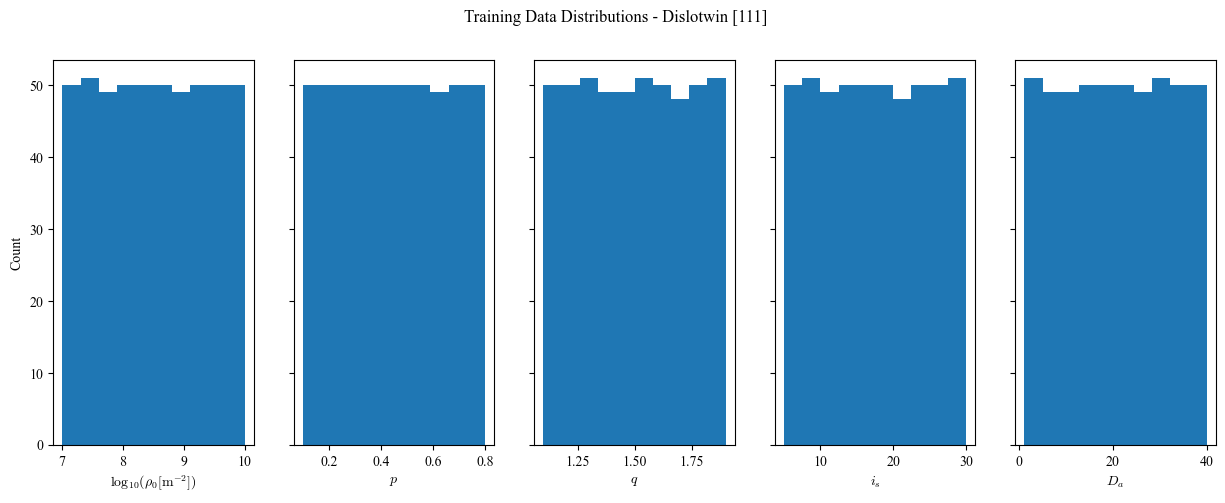

In [9]:
N_inputs_dislo = len(dislo_fitting_param_names)
fig_dislo_111_train_dist,axs_dislo_111_train_dist=plt.subplots(1,N_inputs_dislo,sharey=True,figsize=(15,5))

for i in range(N_inputs_dislo):

    axs_dislo_111_train_dist[i].hist(dislotwin_111_params[:,i])
    axs_dislo_111_train_dist[i].set_xlabel(dislo_fitting_param_names[i], math_fontfamily = 'cm')

axs_dislo_111_train_dist[0].set_ylabel('Count')
fig_dislo_111_train_dist.suptitle('Training Data Distributions - Dislotwin [111]')

Text(0.5, 0.98, 'Training Data Distributions - Dislotwin [001]')

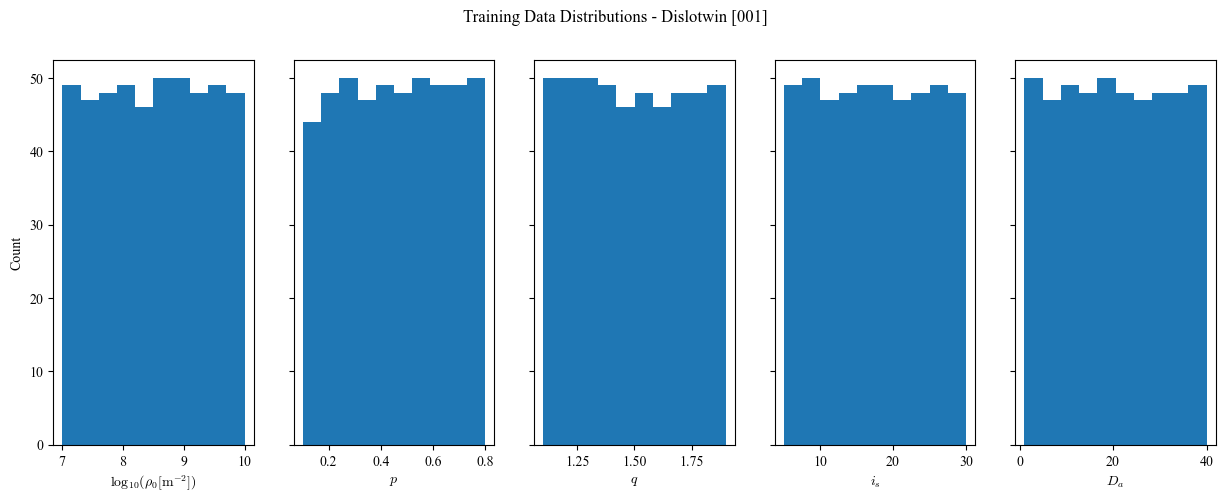

In [10]:
fig_dislo_001_train_dist,axs_dislo_001_train_dist=plt.subplots(1,N_inputs_dislo,sharey=True,figsize=(15,5))

for i in range(N_inputs_dislo):

    axs_dislo_001_train_dist[i].hist(dislotwin_001_params[:,i])
    axs_dislo_001_train_dist[i].set_xlabel(dislo_fitting_param_names[i], math_fontfamily = 'cm')

axs_dislo_001_train_dist[0].set_ylabel('Count')
fig_dislo_001_train_dist.suptitle('Training Data Distributions - Dislotwin [001]')

In [11]:
len(dislotwin_111_params), len(dislotwin_001_params)

(499, 484)

# 2. Surrogate model building - Gaussian Process Regression

In [12]:
dislotwin_111_params = np.array(dislotwin_111_params)
dislotwin_111_outputs = np.array(dislotwin_111_outputs)
dislotwin_001_params = np.array(dislotwin_001_params)
dislotwin_001_outputs = np.array(dislotwin_001_outputs)
X_dislo_train_111 = dislotwin_111_params
Y_dislo_train_111 = dislotwin_111_outputs
X_dislo_train_001 = dislotwin_001_params
Y_dislo_train_001 = dislotwin_001_outputs

In [13]:
dislo_surrogates = [Surrogate(X_dislo_train_111, Y_dislo_train_111, parameter_names = dislo_fitting_param_names), 
              Surrogate(X_dislo_train_001, Y_dislo_train_001, parameter_names = dislo_fitting_param_names)]
for i in range(len(dislo_surrogates)):
    dislo_surrogates[i].scale_data()

In [14]:
for j in range(len(dislo_surrogates)):
    dislo_surrogates[j].build_model(kernel = 1.0 * Matern(length_scale=len(dislo_surrogates[j].parameter_range)*[1],length_scale_bounds = (1e-7, 1e+5), nu=2.5) + 1.0,
                            n_restarts_optimizer=5,
                            cross_validate=True,
                            scoring='r2',
                            normalize_y=True)

Cross validation score:  [1. 1. 1. 1. 1.]
Cross validation score:  [0.98 0.98 0.98 0.98 0.98]


# 3. Performance on test data

In [19]:
Y_test_dislo_prediction_111, Y_test_dislo_error_111 = dislo_surrogates[0].make_prediction(test_dislo_111_params, return_std=True)
Y_test_dislo_prediction_001, Y_test_dislo_error_001 = dislo_surrogates[1].make_prediction(test_dislo_001_params, return_std=True)

Plot examples of surrogate predictions on test data

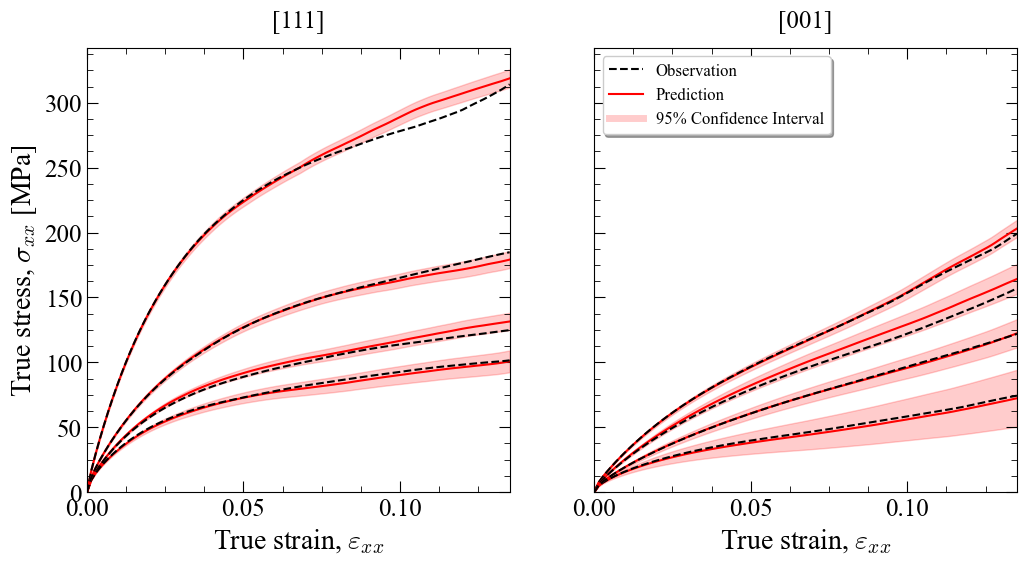

In [182]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import AutoMinorLocator

fig_test, ax_test = plt.subplots(1,2, figsize = (12,6), sharex=True, sharey=True)

np.random.seed(1)

random_dislo_111_samples = np.random.randint(low=0,high=len(test_dislo_111_params), size=4)
random_dislo_001_samples = np.random.randint(low=0,high=len(test_dislo_001_params), size=4)

for idx in random_dislo_111_samples:
    ax_test[0].plot(strain_incs, Y_test_dislo_prediction_111[idx],color='r')
    ax_test[0].fill_between(strain_incs, Y_test_dislo_prediction_111[idx]+2*Y_test_dislo_error_111[idx],Y_test_dislo_prediction_111[idx]-2*Y_test_dislo_error_111[idx],alpha=0.2,color='r')
    ax_test[0].plot(strain_incs, test_dislo_111_outputs[idx],color='k',linestyle='dashed')

for idx in random_dislo_001_samples:
    ax_test[1].plot(strain_incs, Y_test_dislo_prediction_001[idx],color='r')
    ax_test[1].fill_between(strain_incs, Y_test_dislo_prediction_001[idx]+2*Y_test_dislo_error_001[idx],Y_test_dislo_prediction_001[idx]-2*Y_test_dislo_error_001[idx],alpha=0.2,color='r')
    ax_test[1].plot(strain_incs, test_dislo_001_outputs[idx],color='k',linestyle='dashed')

ax_test[0].set_xlim(min(strain_incs), max(strain_incs))
ax_test[1].set_xlim(min(strain_incs), max(strain_incs))
ax_test[0].set_ylim(0)
ax_test[1].set_ylim(0)
ax_test[0].set_xlabel(r'True strain, $\varepsilon_{xx}$', math_fontfamily = 'cm', fontsize = 20)
ax_test[1].set_xlabel(r'True strain, $\varepsilon_{xx}$', math_fontfamily = 'cm', fontsize = 20)
ax_test[0].set_ylabel(r'True stress, $\sigma_{xx}$ [MPa]', math_fontfamily = 'cm', fontsize = 20)

ax_test[0].tick_params(which = 'both', direction = 'in', top = True, right = True, labelsize = 18)
ax_test[0].tick_params(which = 'minor', length = 4)
ax_test[0].tick_params(which = 'major', length = 8)

ax_test[1].tick_params(which = 'both', direction = 'in', top = True, right = True, labelsize = 18)
ax_test[1].tick_params(which = 'minor', length = 4)
ax_test[1].tick_params(which = 'major', length = 8)

ax_test[0].xaxis.set_minor_locator(AutoMinorLocator(4))
ax_test[0].yaxis.set_minor_locator(AutoMinorLocator(4))
ax_test[1].xaxis.set_minor_locator(AutoMinorLocator(4))
ax_test[1].yaxis.set_minor_locator(AutoMinorLocator(4))

#fig_test.suptitle(r'Test Predictions of Phenomenological CP Surrogates', fontsize = 20)
fig_test.subplots_adjust(top=0.85)
ax_test[0].set_title('[111]', fontsize = 18, pad = 15)
ax_test[1].set_title('[001]', fontsize = 18, pad = 15)

#fig_test.suptitle('Test Predictions of Dislocation Density CP Surrogate Models', fontsize = 20)
fig_test.subplots_adjust(top=0.85)

ax_test[0].set_title('[111]', fontsize = 18, pad =15)
ax_test[1].set_title('[001]', fontsize = 18, pad =15)

legend_elements_dislo = [Line2D([0], [0], color='k', label='Observation',ls='dashed'),
                   Line2D([0], [0], color='r', label='Prediction'),
                   Line2D([0], [0], color='r', label='95% Confidence Interval', lw = 5, alpha=0.2)]#lw=5,alpha=0.2)]

ax_test[1].legend(handles=legend_elements_dislo, shadow = True, loc = 'upper left', fontsize = 12)
plt.savefig('./plots/GP_performance_test_data/dislotwin_stress-strain_predictions_test_data.png', dpi = 800)

$r^2$ coefficients for training and testing data

In [38]:
# Predictions on training data
Y_train_dislo_prediction_111, Y_train_dislo_error_111 = dislo_surrogates[0].make_prediction(dislotwin_111_params, return_std=True)
Y_train_dislo_prediction_001, Y_train_dislo_error_001 = dislo_surrogates[1].make_prediction(dislotwin_001_params, return_std=True)

In [39]:
r2_score_dislo_train_111 = sklearn.metrics.r2_score(dislotwin_111_outputs, Y_train_dislo_prediction_111)
r2_score_dislo_train_001 = sklearn.metrics.r2_score(dislotwin_001_outputs, Y_train_dislo_prediction_001)

In [40]:
r2_score_dislo_test_111 = sklearn.metrics.r2_score(test_dislo_111_outputs, Y_test_dislo_prediction_111)
r2_score_dislo_test_001 = sklearn.metrics.r2_score(test_dislo_001_outputs, Y_test_dislo_prediction_001)

In [41]:
r2_score_dislo_train_111, r2_score_dislo_test_111

(1.0, 0.9983451770202979)

In [42]:
r2_score_dislo_train_001, r2_score_dislo_test_001

(1.0, 0.9768530641065312)

Root mean square relative error (RMSRE)

In [43]:
def rmsre(outputs, predictions):
    errors = []
    for i in range(len(outputs)):
        rel_error_per_sim = (outputs[i] - predictions[i])/outputs[i]
        sre_per_sim = rel_error_per_sim**2
        msre_per_sim = np.mean(sre_per_sim)
        errors.append(msre_per_sim)

    rmsre = np.sqrt((1/len(outputs))*np.sum(errors))
    return rmsre

In [44]:
rmsre_dislo_train_111 = rmsre(dislotwin_111_outputs, Y_train_dislo_prediction_111)
rmsre_dislo_train_001 = rmsre(dislotwin_001_outputs, Y_train_dislo_prediction_001)
rmsre_dislo_test_111 = rmsre(test_dislo_111_outputs, Y_test_dislo_prediction_111)
rmsre_dislo_test_001 = rmsre(test_dislo_001_outputs, Y_test_dislo_prediction_001)

In [45]:
rmsre_dislo_train_111, rmsre_dislo_train_001, rmsre_dislo_test_111, rmsre_dislo_test_001

(np.float64(6.774311266674475e-09),
 np.float64(9.5249516712152e-10),
 np.float64(0.02195064931220466),
 np.float64(0.06981306263249165))

Final stress prediction comparison with simulation

Training data

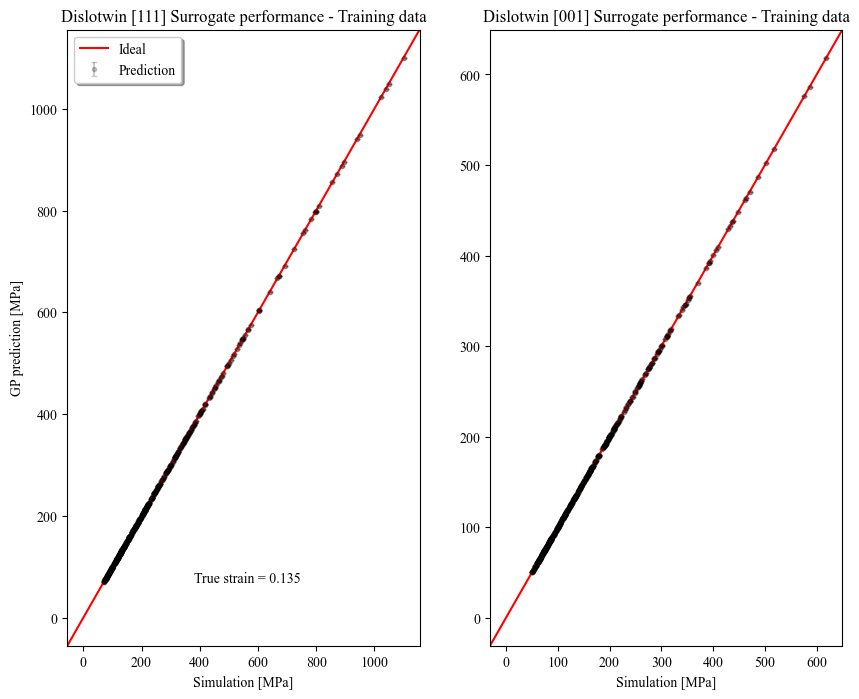

In [46]:
fig_stress, ax_stress = plt.subplots(1,2, figsize = (10,8), sharex=False, sharey=False)

ax_stress[0].plot(dislotwin_111_outputs[:,-1], Y_train_dislo_prediction_111[:,-1], 'ko', markersize = 3, alpha = 0.2)
ax_stress[1].plot(dislotwin_001_outputs[:,-1], Y_train_dislo_prediction_001[:,-1], 'ko', markersize = 3, alpha = 0.2)
ax_stress[0].errorbar(dislotwin_111_outputs[:,-1], Y_train_dislo_prediction_111[:,-1], Y_train_dislo_error_111[:,-1], marker = 'o', markersize = 3, linestyle = 'None', color = 'k', capsize = 2,  label = 'Prediction', alpha = 0.2)
ax_stress[1].errorbar(dislotwin_001_outputs[:,-1], Y_train_dislo_prediction_001[:,-1], Y_train_dislo_error_001[:,-1], marker = 'o', markersize = 3, linestyle = 'None', color = 'k', capsize = 2, alpha = 0.2)
ax_stress[0].set_xlabel('Simulation [MPa]')
ax_stress[1].set_xlabel('Simulation [MPa]')
ax_stress[0].set_ylabel('GP prediction [MPa]')
ax_stress[0].axline([0,0], slope = 1, color = 'r', label = 'Ideal')
ax_stress[1].axline([0,0], slope = 1, color = 'r', label = 'Ideal')
#ax_stress[0].set_xlim(50)
#ax_stress[1].set_xlim(50,400)
#ax_stress[0].set_ylim(50)
#ax_stress[1].set_ylim(50,400)
ax_stress[0].annotate(f'True strain = {strain_incs[-1]}', xy = (380,70))
# Include r^2 value and annotation of final strain value

ax_stress[0].set_title('Dislotwin [111] Surrogate performance - Training data')
ax_stress[1].set_title('Dislotwin [001] Surrogate performance - Training data')
ax_stress[0].legend(shadow = True)

Test data

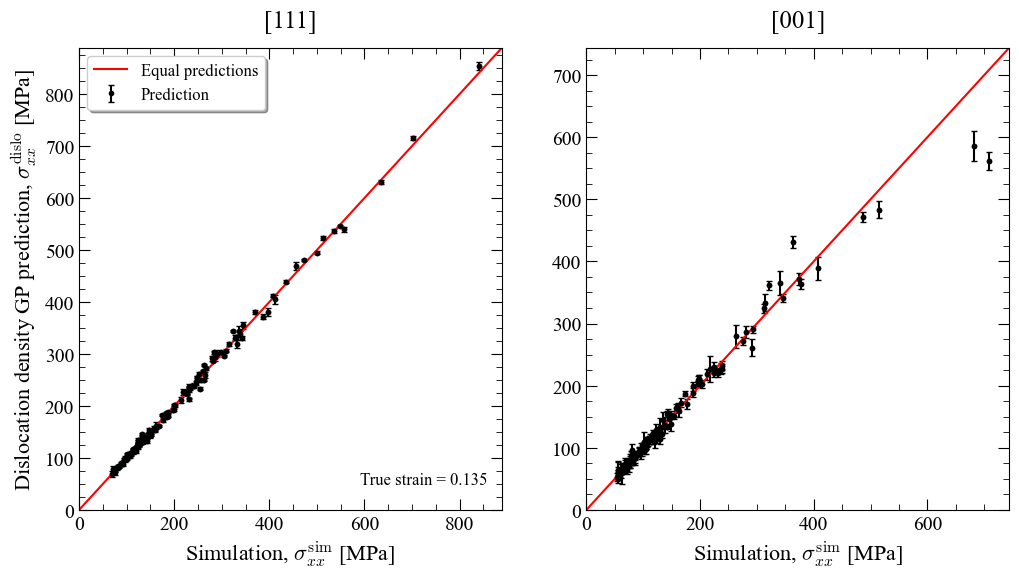

In [189]:
fig_stress, ax_stress = plt.subplots(1,2, figsize = (12,6), sharex=False, sharey=False)

ax_stress[0].plot(test_dislo_111_outputs[:,-1], Y_test_dislo_prediction_111[:,-1], 'ko', markersize = 3)
ax_stress[1].plot(test_dislo_001_outputs[:,-1], Y_test_dislo_prediction_001[:,-1], 'ko', markersize = 3)
ax_stress[0].errorbar(test_dislo_111_outputs[:,-1], Y_test_dislo_prediction_111[:,-1], Y_test_dislo_error_111[:,-1], marker = 'o', markersize = 3, linestyle = 'None', color = 'k', capsize = 2,  label = 'Prediction')
ax_stress[1].errorbar(test_dislo_001_outputs[:,-1], Y_test_dislo_prediction_001[:,-1], Y_test_dislo_error_001[:,-1], marker = 'o', markersize = 3, linestyle = 'None', color = 'k', capsize = 2)
ax_stress[0].set_xlabel(r'Simulation, $\sigma_{xx}^{\text{sim}}$ [MPa]', fontsize = 16, math_fontfamily = 'cm')
ax_stress[1].set_xlabel(r'Simulation, $\sigma_{xx}^{\text{sim}}$ [MPa]', fontsize = 16, math_fontfamily = 'cm')
ax_stress[0].set_ylabel(r'Dislocation density GP prediction, $\sigma_{xx}^{\text{dislo}}$ [MPa]', fontsize = 16, math_fontfamily = 'cm')
ax_stress[0].axline([0,0], slope = 1, color = 'r', label = 'Equal predictions')
ax_stress[1].axline([0,0], slope = 1, color = 'r', label = 'Equal predictions')
ax_stress[0].set_xlim(0, max(max(test_dislo_111_outputs[:,-1]), max(Y_test_dislo_prediction_111[:,-1]))+35)
ax_stress[1].set_xlim(0, max(max(test_dislo_001_outputs[:,-1]), max(Y_test_dislo_prediction_001[:,-1]))+35)
ax_stress[0].set_ylim(0, max(max(test_dislo_111_outputs[:,-1]), max(Y_test_dislo_prediction_111[:,-1]))+35)
ax_stress[1].set_ylim(0, max(max(test_dislo_001_outputs[:,-1]), max(Y_test_dislo_prediction_001[:,-1]))+35)
ax_stress[0].annotate(f'True strain = {strain_incs[-1]}', xy = (590,50), fontsize = 12)
# Include r^2 value and annotation of final strain value

ax_stress[0].tick_params(which = 'both', direction = 'in', top = True, right = True, labelsize = 14)
ax_stress[0].tick_params(which = 'minor', length = 4)
ax_stress[0].tick_params(which = 'major', length = 8)

ax_stress[1].tick_params(which = 'both', direction = 'in', top = True, right = True, labelsize = 14)
ax_stress[1].tick_params(which = 'minor', length = 4)
ax_stress[1].tick_params(which = 'major', length = 8)

ax_stress[0].xaxis.set_minor_locator(AutoMinorLocator(4))
ax_stress[0].yaxis.set_minor_locator(AutoMinorLocator(4))
ax_stress[1].xaxis.set_minor_locator(AutoMinorLocator(4))
ax_stress[1].yaxis.set_minor_locator(AutoMinorLocator(4))

ax_stress[0].set_title('[111]', fontsize = 18, pad = 15)
ax_stress[1].set_title('[001]', fontsize = 18, pad = 15)
ax_stress[0].legend(shadow = True, fontsize = 12)

plt.savefig('./plots/final_stress_comparison/dislotwin_test_predictions_final_stress.png', dpi = 800)

# 4. Calibration

In [54]:
%%time

def mylogloss(X,S,Y): #removed design variable D

    if len(X)!=1:
        X = np.array([X])

    Y_pred_1, Y_pred_error_1  = dislo_surrogates[0].make_prediction(X, return_std=True) # [111] surrogate
    Y_pred_2, Y_pred_error_2  = dislo_surrogates[1].make_prediction(X, return_std=True) # [001] surrogate

    Y_pred = np.vstack([Y_pred_1,Y_pred_2])

    #s2 = (np.abs(S)*Y_pred + 5)**2

    #s2 = (np.linspace(5,0,len(strain_incs)) + S*Y_pred)**2

    #smax = np.ones_like(Y_pred)*5
    #print(smax.shape)
    #smax_choice = np.maximum(smax, S*Y_pred)
    #s2 = (smax_choice)**2 # + (Y_pred_error)**2

    #s_max = np.ones_like(Y_pred)*5 #set threshold uncertainty in stress values up to 2% strain

    #for idx in range(len(Y_pred[0])):
    #    if idx > 14:
    #        s_max[0][idx] = np.abs(S)*Y_pred[0][idx]
    #        s_max[1][idx] = np.abs(S)*Y_pred[1][idx]

    #s2 = s_max**2

    # 2% strain cropping
    strain_incs_cropped_min = [strain_inc for strain_inc in strain_incs if strain_inc < 0.02]
    strain_incs_cropped_max = [strain_inc for strain_inc in strain_incs if strain_inc >= 0.02]

    s_max_111 = np.ones_like(strain_incs_cropped_min)*5
    s_max_001 = np.ones_like(strain_incs_cropped_min)*5

    Y_pred_111_cropped = Y_pred[0][len(strain_incs_cropped_min):]
    Y_pred_001_cropped = Y_pred[1][len(strain_incs_cropped_min):]

    s_prop_111 = np.ones_like(strain_incs_cropped_max)*(np.abs(S)*Y_pred_111_cropped)
    s_prop_001 = np.ones_like(strain_incs_cropped_max)*(np.abs(S)*Y_pred_001_cropped)

    s_111 = np.append(s_max_111, s_prop_111)
    s_001 = np.append(s_max_001, s_prop_001)
    #print(s_111.shape)
    
    s = np.vstack([s_111, s_001])
    #print(s.shape)

    s2 = (s)**2

    error = (0.5*(Y_pred - Y)**2/s2 + 0.5*np.log(2*np.pi*s2))

    return -1*float(error.sum())

def neglogloss(X,S,Y): #removed design variable D

    return -1*mylogloss(X,S,Y)


from typing import Optional, Tuple
import pymc as pm
import pytensor
import pytensor.tensor as pt
from pytensor.graph import Apply, Op
import numpy as np
# define a pytensor Op for our likelihood function

def compile_likelihood(model,params,sigma,data): #removed design variable
    class LogLike(Op):
        def make_node(self,params, sigma, data) -> Apply:
            # Convert inputs to tensor variables
            params = pt.as_tensor(params)
            sigma = pt.as_tensor(sigma)
            #design = pt.as_tensor(design)
            data = pt.as_tensor(data)

            inputs = [params, sigma, data]
            # Define output type, in our case a vector of likelihoods
            # with the same dimensions and same data type as data
            # If data must always be a vector, we could have hard-coded
            # outputs = [pt.vector()]
            outputs = [pt.scalar()]

            # Apply is an object that combines inputs, outputs and an Op (self)
            return Apply(self, inputs, outputs)

        def perform(self, node: Apply, inputs: list[np.ndarray], outputs: list[list[None]]) -> None:
            # This is the method that compute numerical output
            # given numerical inputs. Everything here is numpy arrays
            params, sigma, data = inputs  # this will contain my variables

            # call our numpy log-likelihood function
            loglike_eval = mylogloss(params, sigma, data)

            # Save the result in the outputs list provided by PyTensor
            # There is one list per output, each containing another list
            # pre-populated with a `None` where the result should be saved.
            outputs[0][0] = np.asarray(loglike_eval)

    # create our Op
    loglike_op = LogLike()

    def custom_dist_loglike(data, params, sigma):
        # data, or observed is always passed as the first input of CustomDist
        return loglike_op(params, sigma, data)

    # use PyMC to sampler from log-likelihood
    with model:

        # use a CustomDist with a custom logp function
        likelihood = pm.CustomDist(
            "likelihood", params, sigma, observed=data, logp=custom_dist_loglike
        )

    ip = model.initial_point()

    model.compile_logp(vars=[likelihood], sum=True)(ip)

    return model

CPU times: user 23 μs, sys: 73 μs, total: 96 μs
Wall time: 102 μs


In [55]:
interp_exp_111_stress = single_crystal_analysis.interp_exp_data(exp_111_true_strain, exp_111_true_stress, strain_incs)
interp_exp_001_stress = single_crystal_analysis.interp_exp_data(exp_001_true_strain, exp_001_true_stress, strain_incs)
interp_exp_stress = [interp_exp_111_stress, interp_exp_001_stress]

In [56]:
Y_exp_data = interp_exp_stress
Y_exp_vstack = np.vstack([Y_exp_data[0], Y_exp_data[1]])
Y_exp_vstack.shape

(2, 100)

In [57]:
# Combined parameter ranges
combined_dislo_param_range = []
for i in range(len(dislo_surrogates[0].parameter_range)):
    min_dislo_param_value = max(dislo_surrogates[0].parameter_range[:,0][i], dislo_surrogates[1].parameter_range[:,0][i])
    max_dislo_param_value = min(dislo_surrogates[0].parameter_range[:,1][i], dislo_surrogates[1].parameter_range[:,1][i])
    combined_dislo_param_range.append([min_dislo_param_value, max_dislo_param_value])

combined_dislo_param_range = np.array(combined_dislo_param_range)

In [58]:
dislo_param_diff = combined_dislo_param_range[:,1] - combined_dislo_param_range[:,0]
dislo_param_cut_off_5_percent = 0.05*dislo_param_diff

In [60]:
# MAP estimate
S_exp = 0.01

bounds = scipy.optimize.Bounds(lb=combined_dislo_param_range[:,0]+dislo_param_cut_off_5_percent ,ub=combined_dislo_param_range[:,1]-dislo_param_cut_off_5_percent)

dislo_res = scipy.optimize.differential_evolution(neglogloss,
                                            args=(S_exp, Y_exp_vstack),
                                            bounds=bounds)

print(dislo_res.x)

[ 8.40586819  0.3458755   1.48586784 18.61578042  5.97166015]


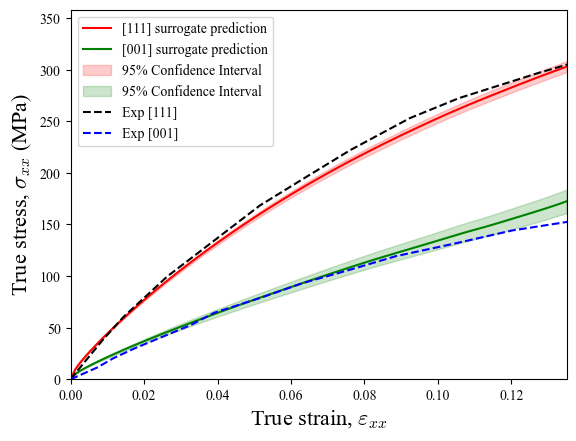

In [61]:
Y_diff_evo_dislo_prediction_111, Y_diff_evo_dislo_prediction_error_111 = dislo_surrogates[0].make_prediction(X = dislo_res.x.reshape(1,-1), return_std=True)
Y_diff_evo_dislo_prediction_001, Y_diff_evo_dislo_prediction_error_001 = dislo_surrogates[1].make_prediction(X = dislo_res.x.reshape(1,-1), return_std=True)
plt.plot(strain_incs, Y_diff_evo_dislo_prediction_111[0], label = '[111] surrogate prediction', color = 'r')
plt.plot(strain_incs, Y_diff_evo_dislo_prediction_001[0], label = '[001] surrogate prediction', color = 'g')
plt.fill_between(strain_incs, Y_diff_evo_dislo_prediction_111[0]-2*Y_diff_evo_dislo_prediction_error_111[0], Y_diff_evo_dislo_prediction_111[0]+2*Y_diff_evo_dislo_prediction_error_111[0], alpha = 0.2, color = 'r', label = '95% Confidence Interval')
plt.fill_between(strain_incs, Y_diff_evo_dislo_prediction_001[0]-2*Y_diff_evo_dislo_prediction_error_001[0], Y_diff_evo_dislo_prediction_001[0]+2*Y_diff_evo_dislo_prediction_error_001[0], alpha = 0.2, color = 'g', label = '95% Confidence Interval')
plt.plot(exp_111_true_strain, exp_111_true_stress, 'k--', label = 'Exp [111]')
plt.plot(exp_001_true_strain, exp_001_true_stress, 'b--', label = 'Exp [001]')
plt.ylabel(r'True stress, $\sigma_{xx}$ (MPa)', fontsize=16, math_fontfamily = 'cm')
plt.xlabel(r'True strain, $\varepsilon_{xx}$', fontsize=16, math_fontfamily = 'cm')
plt.xlim(0,max(strain_incs))
plt.ylim(0)
plt.legend()

In [62]:
dislo_idata_prior = []

draws = 50_000
tune = 50_000
chains = 4
cores = 4

with pm.Model() as dislo_no_grad_model:

    dislo_params = []

    for i in range(dislo_surrogates[0].D):
       
        dislo_distribution = pm.Uniform(name = dislo_surrogates[0].parameter_names[i], 
                                  lower=combined_dislo_param_range[:,0][i], 
                                  upper=combined_dislo_param_range[:,1][i],
                                  initval=dislo_res.x[i]
                                  )
        
        dislo_params.append(dislo_distribution)
    
    #print(type(dislo_params), type(dislo_params[0]))
    
    #params = pm.Uniform(name='params',lower=dislo_surrogates[0].parameter_range[:,0],upper=dislo_surrogates[0].parameter_range[:,1],initval=res.x)
    #dislo_params = pm.Uniform(name='dislo_params',lower=combined_dislo_param_range[:,0],upper=combined_dislo_param_range[:,1],initval=dislo_res.x)
    dislo_sigma_nu = pm.Uniform(name='sigma', lower=0, upper=0.1) # S_exp

    #print(type(dislo_params))

    dislo_no_grad_model = compile_likelihood(model=dislo_no_grad_model, params=dislo_params, sigma=dislo_sigma_nu, data=Y_exp_vstack)

    dislo_step = pm.DEMetropolisZ()

    dislo_idata = pm.sample(step=dislo_step,draws=draws,tune=tune,cores=cores,chains=chains,return_inferencedata=True)

    dislo_idata_prior.append(dislo_idata)

Multiprocess sampling (4 chains in 4 jobs)
DEMetropolisZ: [$\text{log}_{10}(\rho_{0}[\text{m}^{-2}])$, $\it{p}$, $\it{q}$, $\it{i}_{\it{s}}$, $\it{D}_{\it{a}}$, sigma]


Output()

Sampling 4 chains for 50_000 tune and 50_000 draw iterations (200_000 + 200_000 draws total) took 51 seconds.


In [63]:
az.summary(dislo_idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
$\text{log}_{10}(\rho_{0}[\text{m}^{-2}])$,8.407,0.062,8.286,8.521,0.001,0.000,9644.0,15490.0,1.0
$\it{p}$,0.348,0.025,0.301,0.394,0.000,0.000,9323.0,14188.0,1.0
$\it{q}$,1.489,0.017,1.458,1.521,0.000,0.000,9418.0,12930.0,1.0
$\it{i}_{\it{s}}$,18.656,0.160,18.354,18.955,0.002,0.001,9364.0,16878.0,1.0
$\it{D}_{\it{a}}$,5.984,0.200,5.603,6.353,0.002,0.001,9419.0,16550.0,1.0
sigma,0.047,0.003,0.042,0.051,0.000,0.000,9122.0,17017.0,1.0


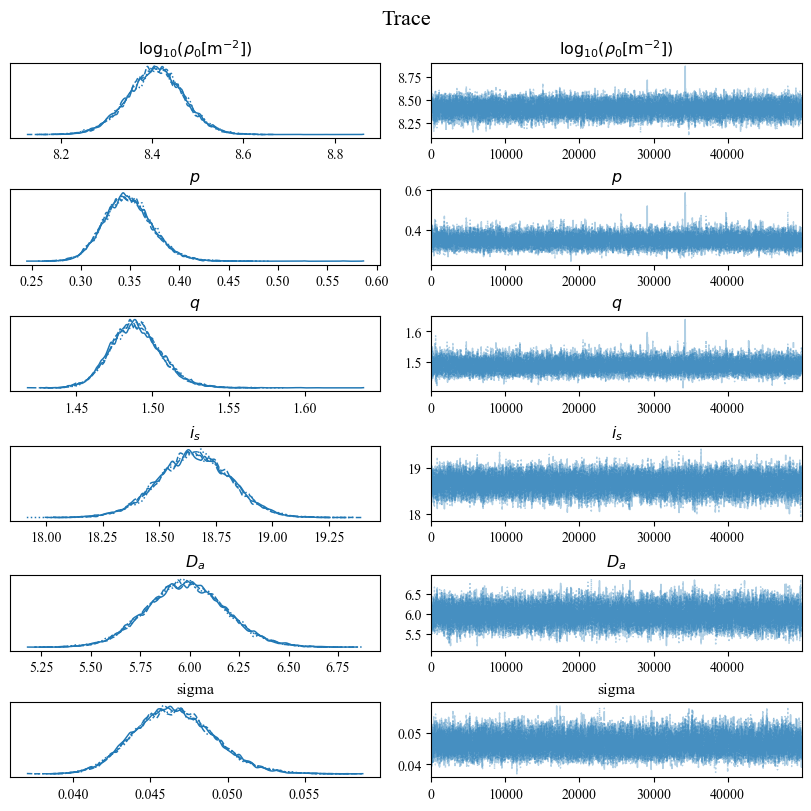

In [64]:
axes_dislo = az.plot_trace(
    data=dislo_idata,
    #var_names = 'dislo_params',
    #coords = {'dislo_params_dim_0': i},
    compact=True,
    backend_kwargs={"figsize": (12, 9), "layout": "constrained"},
    )
plt.gcf().suptitle("Trace", fontsize=16);
plt.gcf().set_figwidth(8)
plt.gcf().set_figheight(8)

Import trace

In [65]:
az.to_netcdf(dislo_idata,'./parameter_traces/dislotwin_parameter_traces_2_percent_strain_err_50k_draws_second_year_report.netcdf')

'./parameter_traces/dislotwin_parameter_traces_2_percent_strain_err_50k_draws_second_year_report.netcdf'

In [66]:
X_posterior_dislo = np.array([np.array(dislo_idata.posterior[x]).flatten() for x in dislo_surrogates[0].parameter_names]).T
X_mode_dislo = np.array([scipy.stats.mode(X_posterior_dislo[:,i])[0] for i in range(len(dislo_surrogates[0].parameter_names))])
X_mean_dislo = np.array([np.mean(X_posterior_dislo[:,i]) for i in range(len(dislo_surrogates[0].parameter_names))])
X_std_dislo = np.array([np.std(X_posterior_dislo[:,i]) for i in range(len(dislo_surrogates[0].parameter_names))])

In [67]:
S_mode_dislo = scipy.stats.mode(np.array(dislo_idata.posterior.sigma).flatten())
S_mode_dislo

ModeResult(mode=np.float64(0.04719955500583222), count=np.int64(42))

# 5. Finding means and correlation plots

In [68]:
def gaussian(x, mu, sigma, a):
    return a*np.exp(-((x-mu)**2)/(2*(sigma)**2))

def dual_gaussian(x, mu_1, mu_2, sigma_1, sigma_2, a1, a2):
    return a1*np.exp(-((x-mu_1)**2)/(2*sigma_1**2)) + a2*np.exp(-((x-mu_2)**2)/(2*sigma_2**2))

def triple_gaussian(x, mu_1, mu_2, mu_3, sigma_1, sigma_2, sigma_3, a1, a2, a3):
    return a1*np.exp(-((x-mu_1)**2)/(2*sigma_1**2)) + a2*np.exp(-((x-mu_2)**2)/(2*sigma_2**2)) + a3*np.exp(-((x-mu_3)**2)/(2*sigma_3**2))

In [69]:
def find_means_and_stdevs(posterior_vals, gaussian, guess, param_range):
    counts, bins, _ = plt.hist(posterior_vals, bins=100, facecolor = 'b')
    xbins = bins[:-1] + (bins[1]-bins[0])/2
    pars, covs = scipy.optimize.curve_fit(gaussian, xbins, counts, p0 = guess)
    param_vals = np.linspace(param_range[0], param_range[1], 1000)
    plt.plot(param_vals, gaussian(param_vals, *pars))
    if gaussian == gaussian:
        means = pars[0]
        stdevs = pars[1]
    if gaussian == dual_gaussian:
        means = [pars[0], pars[1]]
        stdevs = [pars[2]], pars[3]
    if gaussian == triple_gaussian:
        means = [pars[0], pars[1], pars[2]]
        stdevs = [pars[3], pars[4], pars[5]]
    return means, stdevs

(np.float64(8.4082420191247), np.float64(0.06046671466000966))


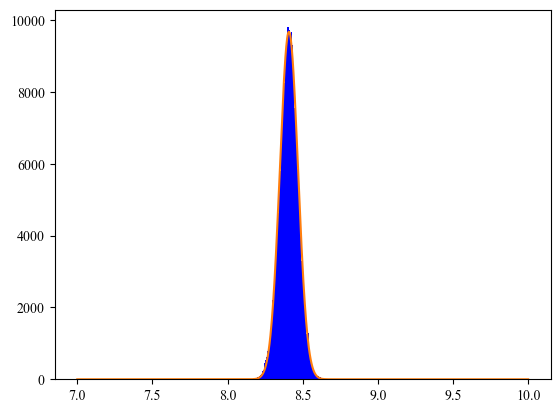

In [70]:
p0_rho_0 = [8.5, 0.1, 3000]
rho_0_mean_and_stdev = find_means_and_stdevs(X_posterior_dislo[:,0], gaussian, p0_rho_0, [7,10])
print(rho_0_mean_and_stdev)

(np.float64(0.34657203679829707), np.float64(0.02411242043893651))


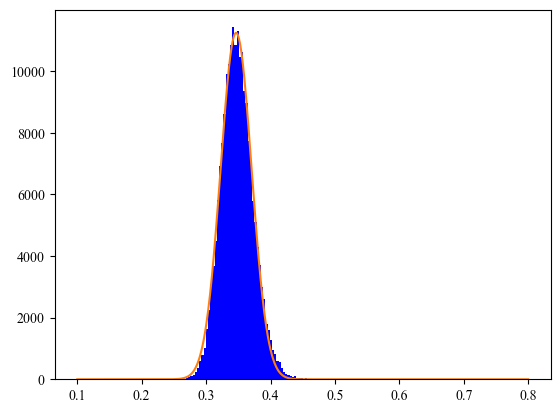

In [71]:
p0_p = [0.3, 0.05, 3000]
p_mean_and_stdev = find_means_and_stdevs(X_posterior_dislo[:,1], gaussian, p0_p, [0.1,0.8])
print(p_mean_and_stdev)

(np.float64(1.488069010238742), np.float64(0.01616747735474147))


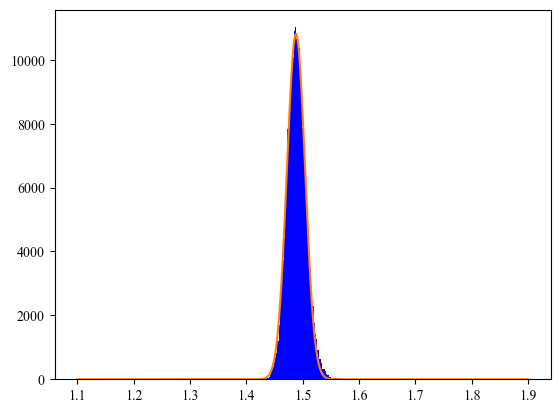

In [75]:
p0_q = [1.5, 0.05, 3000]
q_mean_and_stdev = find_means_and_stdevs(X_posterior_dislo[:,2], gaussian, p0_q, [1.1,1.9])
print(q_mean_and_stdev)

(np.float64(18.656516300871978), np.float64(0.15832249754900155))


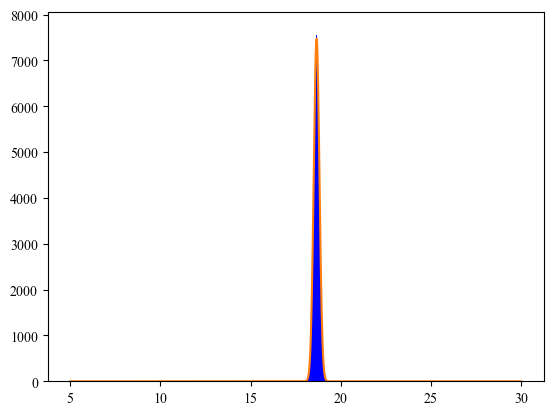

In [76]:
p0_i_s = [18.5, 0.2, 3000]
i_s_mean_and_stdev = find_means_and_stdevs(X_posterior_dislo[:,3], gaussian, p0_i_s, [5,30])
print(i_s_mean_and_stdev)

(np.float64(5.9800687484319495), np.float64(0.19813017726340196))


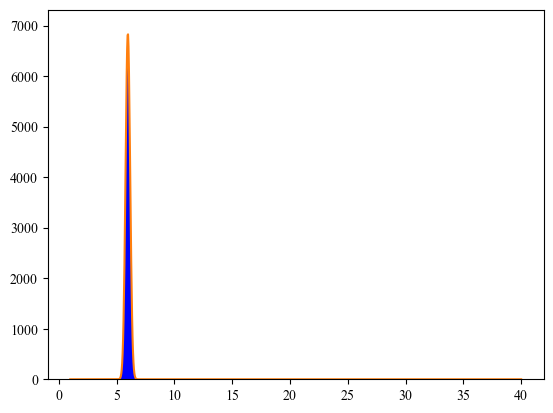

In [77]:
p0_D_a = [5, 0.1, 3000]
D_a_mean_and_stdev = find_means_and_stdevs(X_posterior_dislo[:,4], gaussian, p0_D_a, [1,40])
print(D_a_mean_and_stdev)

In [78]:
S_dislo_posterior = np.array(dislo_idata.posterior['sigma']).flatten()

(np.float64(0.0464188895054221), np.float64(0.002576978577619757))


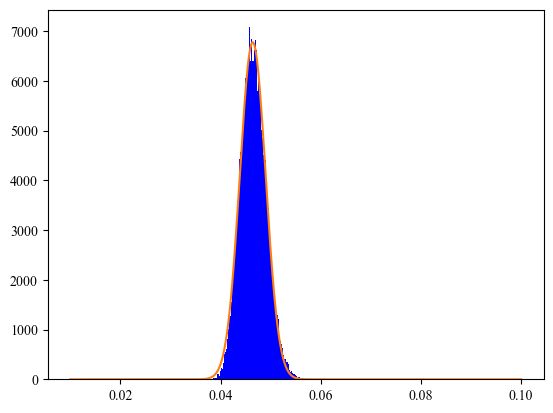

In [79]:
S_dislo_mean_and_stdev = find_means_and_stdevs(S_dislo_posterior, gaussian, [0.045, 0.005, 3000], param_range=[0.01, 0.1])
print(S_dislo_mean_and_stdev)

Galaxy plot

In [80]:
from matplotlib.ticker import AutoMinorLocator, AutoLocator

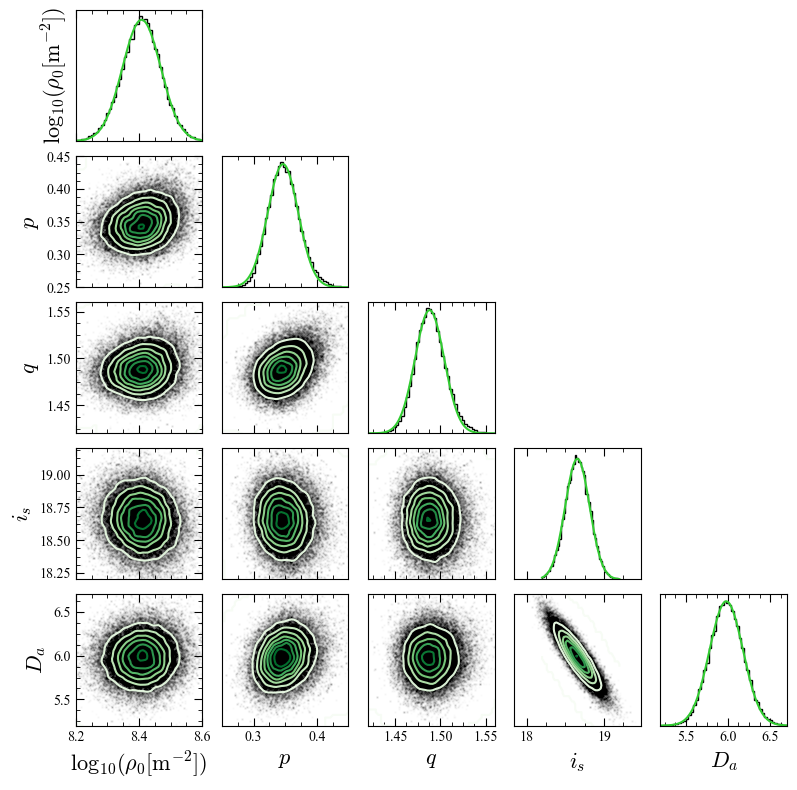

In [191]:
fig_galaxy,ax_galaxy=plt.subplots(len(X_posterior_dislo[0]),len(X_posterior_dislo[0]),figsize=(8,8), sharex='col')
#fig_galaxy.suptitle(f'{1-p}{1-p}1 loading')

for i in range(len(dislo_fitting_param_names)):

    if i == 0 :
            #dislo_param_vals = np.linspace(dislo_surrogates[0].parameter_range[j][0], dislo_surrogates[0].parameter_range[j][1], 1000)
        dislo_param_vals_i = np.linspace(8.2,8.6, 1000)
            
    elif i == 1:
        dislo_param_vals_i = np.linspace(0.25,0.45, 1000)
            #ax_galaxy[j,i].set_xlim(8.2, 8.6)
            
    elif i == 2:
        dislo_param_vals_i = np.linspace(1.42,1.56, 1000)

    elif i == 3:
        dislo_param_vals_i = np.linspace(18.2, 19.2, 1000)

    elif i == 4:
        dislo_param_vals_i = np.linspace(5.2, 6.7, 1000)

    for j in range(len(dislo_fitting_param_names)):

        if j == 0 :
            #dislo_param_vals = np.linspace(dislo_surrogates[0].parameter_range[j][0], dislo_surrogates[0].parameter_range[j][1], 1000)
            dislo_param_vals_j = np.linspace(8.2,8.6, 1000)
            
        elif j == 1:
            dislo_param_vals_j = np.linspace(0.25,0.45, 1000)
            #ax_galaxy[j,i].set_xlim(8.2, 8.6)
            
        elif j == 2:
            dislo_param_vals_j = np.linspace(1.42,1.56, 1000)

        elif j == 3:
            dislo_param_vals_j = np.linspace(18.2, 19.2, 1000)

        elif j == 4:
            dislo_param_vals_j = np.linspace(5.2, 6.7, 1000)

        if i==j:

            dislo_param_counts, dislo_param_bins, _ = ax_galaxy[j,i].hist(X_posterior_dislo[:,j],range = (min(dislo_param_vals_j), max(dislo_param_vals_j)), bins=50, facecolor = 'None', edgecolor = 'k', histtype = 'step')
            dislo_param_xbins = dislo_param_bins[:-1] + (dislo_param_bins[1]-dislo_param_bins[0])/2
            if j == 0:
                p0 = p0_rho_0
            if j == 1:
                p0 = p0_p
            if j == 2:
                p0 = p0_q
            if j == 3:
                p0 = p0_i_s
            if j == 4:
                p0 = p0_D_a

            dislo_pars, dislo_covs = scipy.optimize.curve_fit(gaussian, dislo_param_xbins, dislo_param_counts, p0)

            #if j == 0 :
            #    #dislo_param_vals = np.linspace(dislo_surrogates[0].parameter_range[j][0], dislo_surrogates[0].parameter_range[j][1], 1000)
            #    dislo_param_vals = np.linspace(8.2,8.6, 1000)
            
            #elif j == 1:
            #    dislo_param_vals = np.linspace(0.25,0.45, 1000)
            #    #ax_galaxy[j,i].set_xlim(8.2, 8.6)
            
            #elif j == 2:
            #    dislo_param_vals = np.linspace(1.44,1.56, 1000)

            #elif j == 3:
            #    dislo_param_vals = np.linspace(18.2, 19.2, 1000)

            #elif j == 4:
            #    dislo_param_vals = np.linspace(5.2, 6.7, 1000)

            ax_galaxy[j,i].plot(dislo_param_vals_j, gaussian(dislo_param_vals_j, *dislo_pars), 'limegreen')
            ax_galaxy[j,i].set_xlim(min(dislo_param_vals_j), max(dislo_param_vals_j))
            #    ax_galaxy[j,i].plot(dislo_param_vals, fit_type(dislo_param_vals, *dislo_pars), 'limegreen')

            if j < 3:
                ax_galaxy[j,i].set_yticklabels([])
                ax_galaxy[j,i].set_xticklabels([])
                ax_galaxy[j,i].set_yticks([])

            else:
                ax_galaxy[j,i].set_yticklabels([])
                ax_galaxy[j,i].set_yticks([])
    

        else:
            counts,ybins,xbins,image  = ax_galaxy[j,i].hist2d(X_posterior_dislo[:,i],X_posterior_dislo[:,j],bins=50, range = [[min(dislo_param_vals_i),max(dislo_param_vals_i)],[min(dislo_param_vals_j),max(dislo_param_vals_j)]], cmap='binary')#,norm='log')
            ax_galaxy[j,i].clear()
            
            ax_galaxy[j,i].plot(X_posterior_dislo[:,i],X_posterior_dislo[:,j], lw=0,ls='-',marker='.',markersize=1.0,color='k',alpha=0.02)

            counts = scipy.ndimage.gaussian_filter(counts, sigma=1.0)

            ax_galaxy[i,j].contour(counts,extent=[xbins.min(),xbins.max(),ybins.min(),ybins.max()],cmap='Greens',antialiased=True,levels=7)

            ax_galaxy[j,i].set_ylim(min(dislo_param_vals_j), max(dislo_param_vals_j))

        ax_galaxy[j,i].xaxis.set_minor_locator(AutoMinorLocator(4))
        ax_galaxy[j,i].yaxis.set_minor_locator(AutoMinorLocator(4))
                    
        ax_galaxy[j,i].tick_params(which = 'both', direction = 'in', top = True)
        ax_galaxy[j,i].tick_params(which = 'minor', length = 3)
        ax_galaxy[j,i].tick_params(which = 'major', length = 6)

        if j != i:
            ax_galaxy[j,i].tick_params(which = 'both', direction = 'in', right = True)

        if j > i:
            fig_galaxy.delaxes(ax_galaxy[i,j])

        if j > 0:
            ax_galaxy[i,j].set_yticks([])

        if j==0:
            ax_galaxy[i,j].set_ylabel(dislo_fitting_param_names[i], math_fontfamily = 'cm', fontsize = 16)

        if i==len(X_posterior_dislo[0])-1:
            ax_galaxy[i,j].set_xlabel(dislo_fitting_param_names[j], math_fontfamily = 'cm', fontsize = 16)
            
        else:            
            #ax[i,j].set_xlim(0.5,1.0)
            pass

#ax_galaxy[0,0].set_yticklabels([])
#ax_galaxy[0,0].set_yticks([])

fig_galaxy.tight_layout()

plt.savefig('./plots/galaxy_plots/dislotwin_galaxy_plot_parallel_calibration_2_percent_strain_err_second_year_report.png', dpi = 800)

# 6. Plotting calibration results

In [ ]:
#q_mean = X_mean_dislo[2]
#q_stdev = X_std_dislo[2]

In [83]:
mean_params = [rho_0_mean_and_stdev[0], p_mean_and_stdev[0], q_mean_and_stdev[0], i_s_mean_and_stdev[0], D_a_mean_and_stdev[0]]
mean_stdevs = [rho_0_mean_and_stdev[1], p_mean_and_stdev[1], q_mean_and_stdev[1], i_s_mean_and_stdev[1], D_a_mean_and_stdev[1]]

In [84]:
y_opt_dislo_111, y_opt_err_dislo_111 = dislo_surrogates[0].make_prediction(np.array(mean_params).reshape(1, -1), return_std=True)
y_opt_dislo_001, y_opt_err_dislo_001 = dislo_surrogates[1].make_prediction(np.array(mean_params).reshape(1, -1), return_std=True)

In [85]:
#Calculating confidence interval for 2% strain threshold given mean_params

strain_incs_cropped_min = [strain_inc for strain_inc in strain_incs if strain_inc < 0.02]
strain_incs_cropped_max = [strain_inc for strain_inc in strain_incs if strain_inc >= 0.02]

y_opt_dislo_111_cropped = y_opt_dislo_111[0][len(strain_incs_cropped_min):]
y_opt_dislo_001_cropped = y_opt_dislo_001[0][len(strain_incs_cropped_min):]

dislo_111_exp_err_max = np.ones_like(strain_incs_cropped_min)*5
dislo_001_exp_err_max = np.ones_like(strain_incs_cropped_min)*5

dislo_111_exp_err_prop = np.ones_like(strain_incs_cropped_max)*(np.abs(S_dislo_mean_and_stdev[0])*y_opt_dislo_111_cropped)
dislo_001_exp_err_prop = np.ones_like(strain_incs_cropped_max)*(np.abs(S_dislo_mean_and_stdev[0])*y_opt_dislo_001_cropped)

dislo_111_exp_err = np.append(dislo_111_exp_err_max, dislo_111_exp_err_prop)
dislo_001_exp_err = np.append(dislo_001_exp_err_max, dislo_001_exp_err_prop)

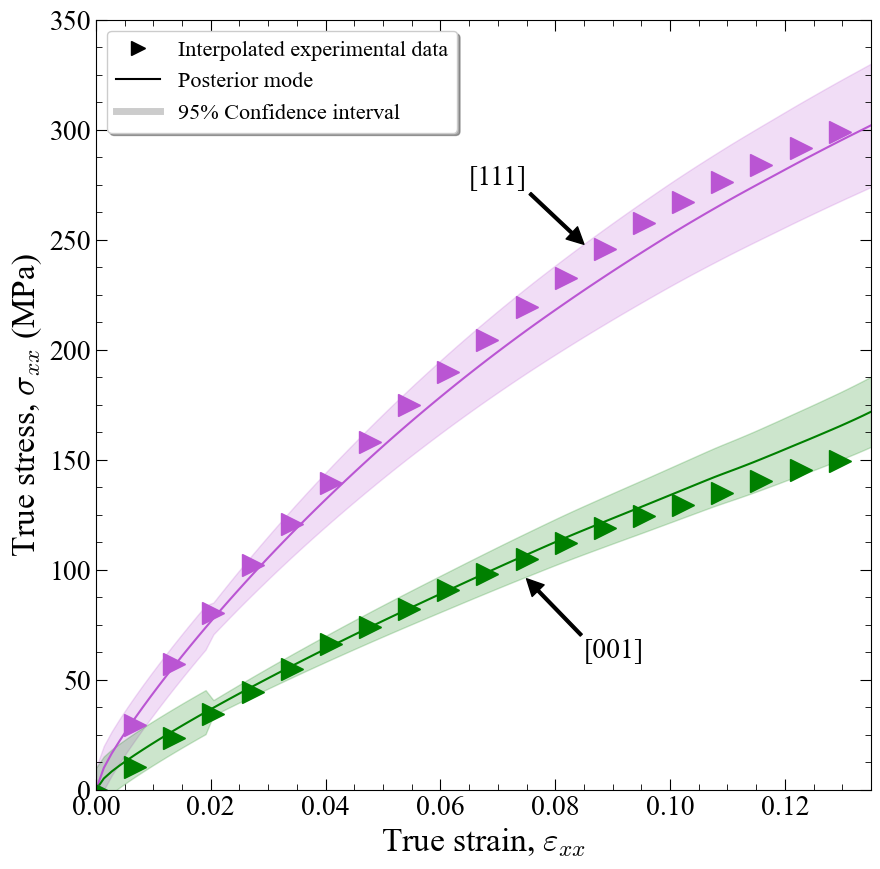

In [195]:
from matplotlib.lines import Line2D

fig_cali_dislo = plt.figure(figsize = (10,10))
ax_cali_dislo = fig_cali_dislo.add_subplot(1,1,1)

#ax_cali_dislo.set_title('Dislotwin calibration', fontsize = 24)

ax_cali_dislo.plot(strain_incs, y_opt_dislo_111[0], color='mediumorchid',ls='-')
ax_cali_dislo.plot(strain_incs, y_opt_dislo_001[0], color='g',ls='-')
ax_cali_dislo.plot(strain_incs[::5], interp_exp_111_stress[::5],color='mediumorchid',ls='None', marker = '>', markersize = 16)#lw=3)
ax_cali_dislo.plot(strain_incs[::5], interp_exp_001_stress[::5],color='g',ls='None', marker = '>', markersize = 16)

# Experimental
#ax_cali.fill_between(strain_incs,interp_exp_stress[0]+2*errors[0],interp_exp_stress[0]-2*errors[0],color='k',alpha=0.2) #range(len(interp_exp_stress))
#ax_cali.fill_between(strain_incs,interp_exp_stress[1]+2*errors[1],interp_exp_stress[1]-2*errors[1],color='g',alpha=0.2) #range(len(interp_exp_stress))

# Surrogate error
#ax_cali_dislo.fill_between(strain_incs,y_opt_dislo_111[0]+2*y_opt_err_dislo_111[0],y_opt_dislo_111[0]-2*y_opt_err_dislo_111[0],color='mediumorchid', alpha=0.2) #range(len(y_opt[0]))
#ax_cali_dislo.fill_between(strain_incs,y_opt_dislo_001[0]+2*y_opt_err_dislo_001[0],y_opt_dislo_001[0]-2*y_opt_err_dislo_001[0],color='g', alpha=0.2) #range(len(y_opt[0]))

# Total uncertainty is GP uncertainty + experimental uncertainty (S_exp)
#ax_cali_dislo.fill_between(strain_incs,y_opt_dislo_111[0]+ 2*S_mode_dislo[0]*y_opt_dislo_111[0], y_opt_dislo_111[0]- 2*S_mode_dislo[0]*y_opt_dislo_111[0], color='r', alpha=0.2) #range(len(y_opt[0]))
#ax_cali_dislo.fill_between(strain_incs,y_opt_dislo_001[0]+ 2*S_mode_dislo[0]*y_opt_dislo_001[0], y_opt_dislo_001[0]- 2*S_mode_dislo[0]*y_opt_dislo_001[0], color='b', alpha=0.2) #range(len(y_opt[0]))

#error_opt_dislo_111 = np.maximum(np.ones_like(y_opt_dislo_111[0])*5, S_dislo_mean_and_stdev[0][1]*y_opt_dislo_111[0])
#error_opt_dislo_001 = np.maximum(np.ones_like(y_opt_dislo_001[0])*5, S_dislo_mean_and_stdev[0][1]*y_opt_dislo_001[0])

#--------------------------------------------------------------------
### Write new errors with 5 MPa up to 2% strain here!!!
error_opt_dislo_111 = dislo_111_exp_err
error_opt_dislo_001 = dislo_001_exp_err

#--------------------------------------------------------------------

#error_opt_dislo_111 = (S_mode_dislo[0]*y_opt_dislo_111[0] + 5)
#error_opt_dislo_001 = (S_mode_dislo[0]*y_opt_dislo_001[0] + 5)

#error_opt_dislo_111 = (S_mode_dislo[0]*y_opt_dislo_111[0] + np.linspace(5,0,len(strain_incs)))
#error_opt_dislo_001 = (S_mode_dislo[0]*y_opt_dislo_001[0] + np.linspace(5,0,len(strain_incs)))

#print(error_opt_dislo_111, error_opt_dislo_001)

ax_cali_dislo.fill_between(strain_incs,y_opt_dislo_111[0]+ 2*error_opt_dislo_111, y_opt_dislo_111[0]- 2*error_opt_dislo_111, color='mediumorchid', alpha=0.2) #range(len(y_opt[0]))
ax_cali_dislo.fill_between(strain_incs,y_opt_dislo_001[0]+ 2*error_opt_dislo_001, y_opt_dislo_001[0]- 2*error_opt_dislo_001, color='g', alpha=0.2) 

# Direct simulations from calibrated parameter sets

#ax_unc.plot(direct_dislo_111_strain, direct_dislo_111_stress, color='magenta', ls = '-.')
#ax_unc.plot(direct_dislo_001_strain, direct_dislo_001_stress, color='orange', ls = '-.')

legend_elements_cali_dislo = [Line2D([0],[0], color = 'k', label = 'Interpolated experimental data', marker = '>', markersize = 10, ls = 'None'),
                              Line2D([0],[0], color = 'k', label = 'Posterior mode'),
                              Line2D([0],[0], color = 'k', label = '95% Confidence interval', lw = 5, alpha = 0.2)]

#legend_elements_cali_dislo = [Line2D([0], [0], color='k', label='Observation 111',marker = '>', ls = 'None'),
                   #Line2D([0], [0], color='k', label='Observation CI 111 ', lw=5,alpha=0.2),
#                   Line2D([0], [0], color='g', label='Observation 001',marker = '>', ls = 'None'),
                   #Line2D([0], [0], color='g', label='Observation CI 001 ', lw=5,alpha=0.2),
#                   Line2D([0], [0], color='r', label='Posterior mode 111'),
#                   Line2D([0], [0], color='r', label='Posterior CI 111', lw=5,alpha=0.2),
#                   Line2D([0], [0], color='b', label='Posterior mode 001'),
                   #Line2D([0], [0], color='k', label='Observation CI 111 ', lw=5,alpha=0.2),
#                   Line2D([0], [0], color='b', label='Posterior CI 001', lw=5,alpha=0.2),
                   #Line2D([0], [0], color='g', label='Phenopowerlaw simulation', ls='dashdot'),
                   #Line2D([0], [0], color = 'magenta', ls = '-.', label = 'Direct [111] sim', lw = 5),
                   #Line2D([0], [0], color = 'orange', ls = '-.', label = 'Direct [001] sim', lw = 5)
#                    ]


ax_cali_dislo.annotate('[111]', xy=(0.085, 248), xytext=(0.065,275), color = 'k', fontsize = 20, arrowprops=dict(facecolor = 'k', edgecolor = 'k', width = 2))
ax_cali_dislo.annotate('[001]', xy=(0.075, 96), xytext=(0.085,60), color = 'k', fontsize = 20, arrowprops=dict(facecolor = 'k', edgecolor = 'k', width = 2))

ax_cali_dislo.set_xlim(min(strain_incs), max(strain_incs))
ax_cali_dislo.set_ylim(0,350)
ax_cali_dislo.set_xlabel(r'True strain, $\varepsilon_{xx}$', fontsize = 24, math_fontfamily = 'cm')
ax_cali_dislo.set_ylabel(r'True stress, $\sigma_{xx}$ (MPa)', fontsize = 24, math_fontfamily = 'cm')
ax_cali_dislo.tick_params(which = 'both', direction = 'in', top = True, right = True, labelsize = 20)
ax_cali_dislo.tick_params(which = 'minor', length = 4)
ax_cali_dislo.tick_params(which = 'major', length = 8)

ax_cali_dislo.xaxis.set_minor_locator(AutoMinorLocator(4))
ax_cali_dislo.yaxis.set_minor_locator(AutoMinorLocator(4))

ax_cali_dislo.legend(handles=legend_elements_cali_dislo, ncol=1, fontsize = 16, shadow = True)

#plt.savefig('./plots/stress_strain_calibration/dislotwin_calibrated_stress-strain_curves_with_exp_uncertainty.png', dpi=800)

Image in report at the moment uses larger peak in S to calculate error (3.6%)

2% strain at increment 14 - construct uncertainty with 5 MPa error up to this point then change to $SY_{pred}$

# 7. Sensitivity analysis

In [139]:
dislo_surrogates[0].parameter_range

array([[ 7.00183626,  9.99949512],
       [ 0.10017974,  0.79965692],
       [ 1.10070778,  1.89887554],
       [ 5.01515153, 29.96737022],
       [ 1.06470722, 39.94950275]])

In [142]:
# Set parameter ranges according to MCMC posteriors
posterior_param_range = np.array([[8.2,8.6], [0.25,0.45], [1.42,1.56], [18,19.2], [5.2,6.7]])

dislo_surrogates[0].parameter_range = posterior_param_range
dislo_surrogates[1].parameter_range = posterior_param_range

In [90]:
dislo_surrogates[0].parameter_mean = mean_params
dislo_surrogates[1].parameter_mean = mean_params
dislo_surrogates[0].parameter_std = mean_stdevs
dislo_surrogates[1].parameter_std = mean_stdevs

In [130]:
dislo_surrogates[0].parameter_std

[np.float64(0.06046671466000966),
 np.float64(0.02411242043893651),
 np.float64(0.01616747735474147),
 np.float64(0.15832249754900155),
 np.float64(0.19813017726340196)]

In [143]:
local_sobol_dislo_111 = dislo_surrogates[0].generate_sobol(n=2**10, use_fit = False)
local_sobol_dislo_001 = dislo_surrogates[1].generate_sobol(n=2**10, use_fit = False)
boot_dislo_111 = local_sobol_dislo_111.bootstrap()
boot_dislo_001 = local_sobol_dislo_001.bootstrap()

/opt/homebrew/Cellar/micromamba/2.0.8/envs/pymc-env/lib/python3.13/site-packages/scipy/stats/_sensitivity_analysis.py:149: RuntimeWarning: invalid value encountered in divide
  s = np.mean(f_B * (f_AB - f_A), axis=-1) / var  # Table 2 (b)
/opt/homebrew/Cellar/micromamba/2.0.8/envs/pymc-env/lib/python3.13/site-packages/scipy/stats/_sensitivity_analysis.py:150: RuntimeWarning: invalid value encountered in divide
  st = 0.5 * np.mean((f_A - f_AB) ** 2, axis=-1) / var  # Table 2 (f)
/opt/homebrew/Cellar/micromamba/2.0.8/envs/pymc-env/lib/python3.13/site-packages/scipy/_lib/_util.py:352: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


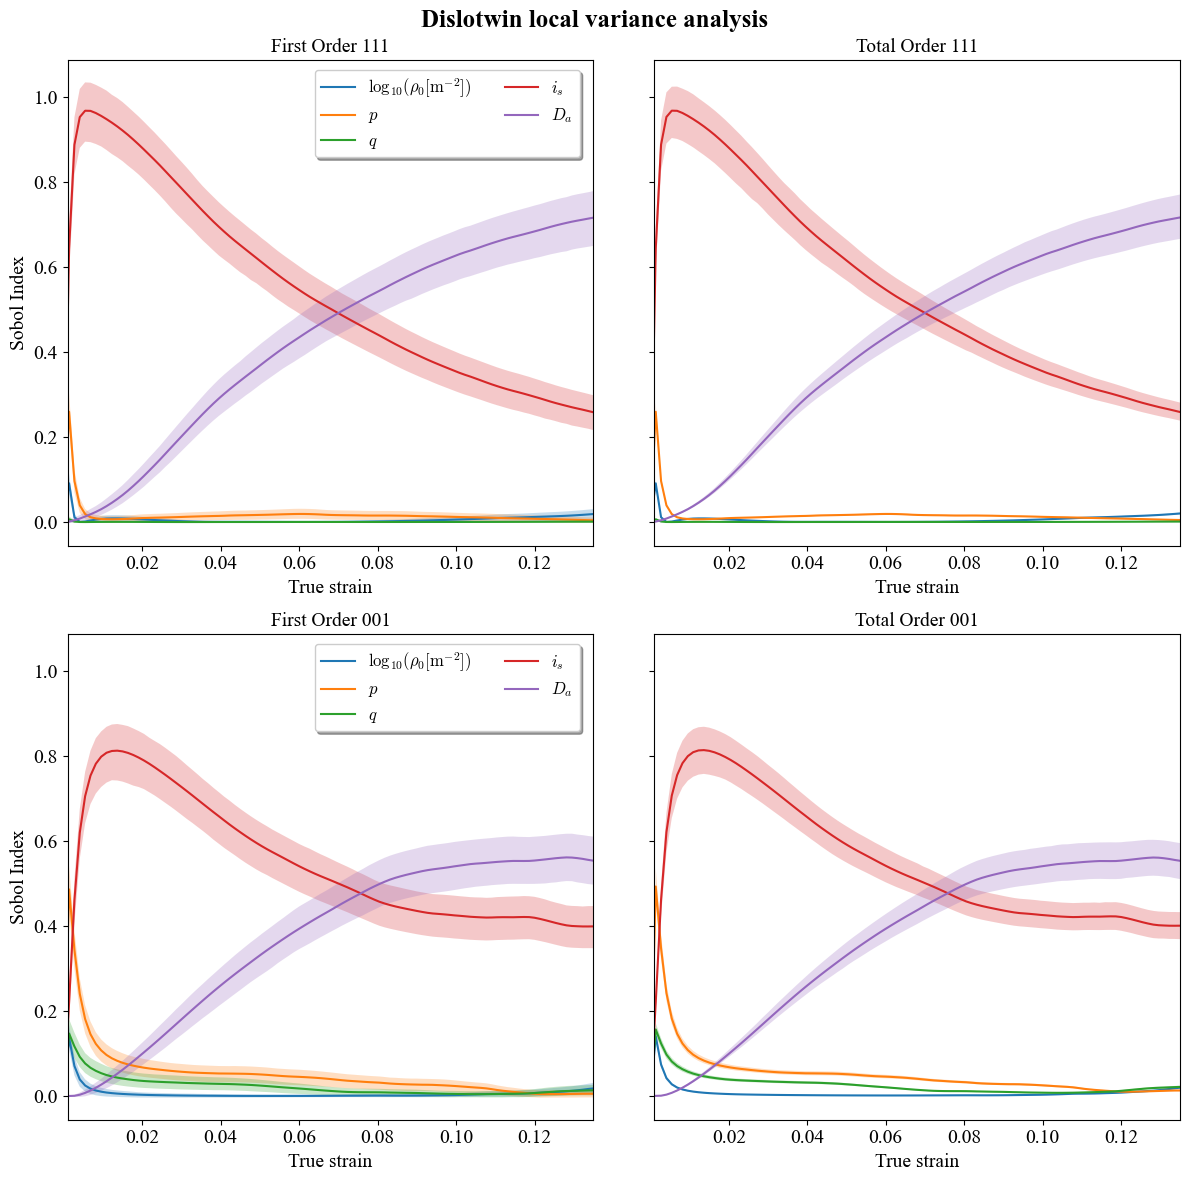

In [154]:
fig_dislo_sobol,axs_dislo_sobol=plt.subplots(2,2,sharey=True,figsize=(12,12))

for i in range(len(dislo_fitting_param_names)):

    axs_dislo_sobol[0][0].fill_between(x=strain_incs,
                    y1=boot_dislo_111.first_order.confidence_interval.low[:,i],
                    y2=boot_dislo_111.first_order.confidence_interval.high[:,i],
                    alpha=0.25)
    axs_dislo_sobol[0][1].fill_between(x=strain_incs,
                    y1=boot_dislo_111.total_order.confidence_interval.low[:,i],
                    y2=boot_dislo_111.total_order.confidence_interval.high[:,i],
                    alpha=0.25)
    axs_dislo_sobol[1][0].fill_between(x=strain_incs,
                    y1=boot_dislo_001.first_order.confidence_interval.low[:,i],
                    y2=boot_dislo_001.first_order.confidence_interval.high[:,i],
                    alpha=0.25)
    axs_dislo_sobol[1][1].fill_between(x=strain_incs,
                    y1=boot_dislo_001.total_order.confidence_interval.low[:,i],
                    y2=boot_dislo_001.total_order.confidence_interval.high[:,i],
                    alpha=0.25)
    
    axs_dislo_sobol[0][0].plot(strain_incs,local_sobol_dislo_111.first_order[:,i],label=fr'{dislo_fitting_param_names[i]}') #label=fitting_param_names[i])
    axs_dislo_sobol[0][1].plot(strain_incs,local_sobol_dislo_111.total_order[:,i],label=fr'{dislo_fitting_param_names[i]}')
    axs_dislo_sobol[1][0].plot(strain_incs,local_sobol_dislo_001.first_order[:,i],label=fr'{dislo_fitting_param_names[i]}') #label=fitting_param_names[i])
    axs_dislo_sobol[1][1].plot(strain_incs,local_sobol_dislo_001.total_order[:,i],label=fr'{dislo_fitting_param_names[i]}')

#Graph stuff
fig_dislo_sobol.suptitle('Dislotwin local variance analysis',weight='bold', fontsize = 18)
#fig.suptitle('Polycrystalline copper variance analysis',weight='bold', fontsize = 18)

L_111 = axs_dislo_sobol[0][0].legend(loc = (0.47, 0.8), ncol = 2, fontsize = 12, shadow = True)
axs_dislo_sobol[0][0].set_ylabel('Sobol Index', fontsize=14)
axs_dislo_sobol[0][0].set_xlabel('True strain', fontsize=14)
axs_dislo_sobol[0][1].set_xlabel('True strain', fontsize=14)

L_001 = axs_dislo_sobol[1][0].legend(loc = (0.47, 0.8), ncol = 2, fontsize = 12, shadow = True)
axs_dislo_sobol[1][0].set_ylabel('Sobol Index', fontsize=14)
axs_dislo_sobol[1][0].set_xlabel('True strain', fontsize=14)
axs_dislo_sobol[1][1].set_xlabel('True strain', fontsize=14)
#axs[0].set_xscale('log')
#axs[1].set_xscale('log')
#axs_dislo_sobol[0][0].set_xlim(min(strain_incs), max(strain_incs))
#axs_dislo_sobol[0][1].set_xlim(min(strain_incs), max(strain_incs))
#axs_dislo_sobol[1][0].set_xlim(min(strain_incs), max(strain_incs))
#axs_dislo_sobol[1][1].set_xlim(min(strain_incs), max(strain_incs))
#axs[0].set_ylim(1e-3)
#axs[1].set_ylim(1e-3)

for text in L_111.get_texts():
    text.set_math_fontfamily('cm')
for text in L_001.get_texts():
    text.set_math_fontfamily('cm')

axs_dislo_sobol[0][0].set_xlim(0.001, max(strain_incs))
axs_dislo_sobol[0][1].set_xlim(0.001, max(strain_incs))
axs_dislo_sobol[1][0].set_xlim(0.001, max(strain_incs))
axs_dislo_sobol[1][1].set_xlim(0.001, max(strain_incs))



axs_dislo_sobol[0][0].set_title('First Order 111', fontsize=14)
axs_dislo_sobol[0][1].set_title('Total Order 111', fontsize=14)
axs_dislo_sobol[1][0].set_title('First Order 001', fontsize=14)
axs_dislo_sobol[1][1].set_title('Total Order 001', fontsize=14)
axs_dislo_sobol[0][0].tick_params(labelsize=14)
axs_dislo_sobol[0][1].tick_params(labelsize=14)
axs_dislo_sobol[1][0].tick_params(labelsize=14)
axs_dislo_sobol[1][1].tick_params(labelsize=14)
#axs[0].set_yscale('log')
#axs[1].set_yscale('log')

fig_dislo_sobol.tight_layout()

Dislo 111 plots

In [156]:
local_sobol_dislo_111_final = dislo_surrogates[0].generate_sobol(n=2**12, use_fit=False)
boot_dislo_111_final = local_sobol_dislo_111_final.bootstrap()

/opt/homebrew/Cellar/micromamba/2.0.8/envs/pymc-env/lib/python3.13/site-packages/scipy/stats/_sensitivity_analysis.py:149: RuntimeWarning: invalid value encountered in divide
  s = np.mean(f_B * (f_AB - f_A), axis=-1) / var  # Table 2 (b)
/opt/homebrew/Cellar/micromamba/2.0.8/envs/pymc-env/lib/python3.13/site-packages/scipy/stats/_sensitivity_analysis.py:150: RuntimeWarning: invalid value encountered in divide
  st = 0.5 * np.mean((f_A - f_AB) ** 2, axis=-1) / var  # Table 2 (f)
/opt/homebrew/Cellar/micromamba/2.0.8/envs/pymc-env/lib/python3.13/site-packages/scipy/_lib/_util.py:352: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


In [165]:
from itertools import cycle
SA_lines_first = ["-","--","-.",":"]
SA_lines_total = ["-","--","-.",":"]
SA_linecycler_first = cycle(SA_lines_first)
SA_linecycler_total = cycle(SA_lines_total)

colors_first = ["green", "red", "k", "c", "mediumorchid"]
colors_total = ["green", "red", "k", "c", "mediumorchid"]
color_cycler_first = cycle(colors_first)
color_cycler_total = cycle(colors_total)

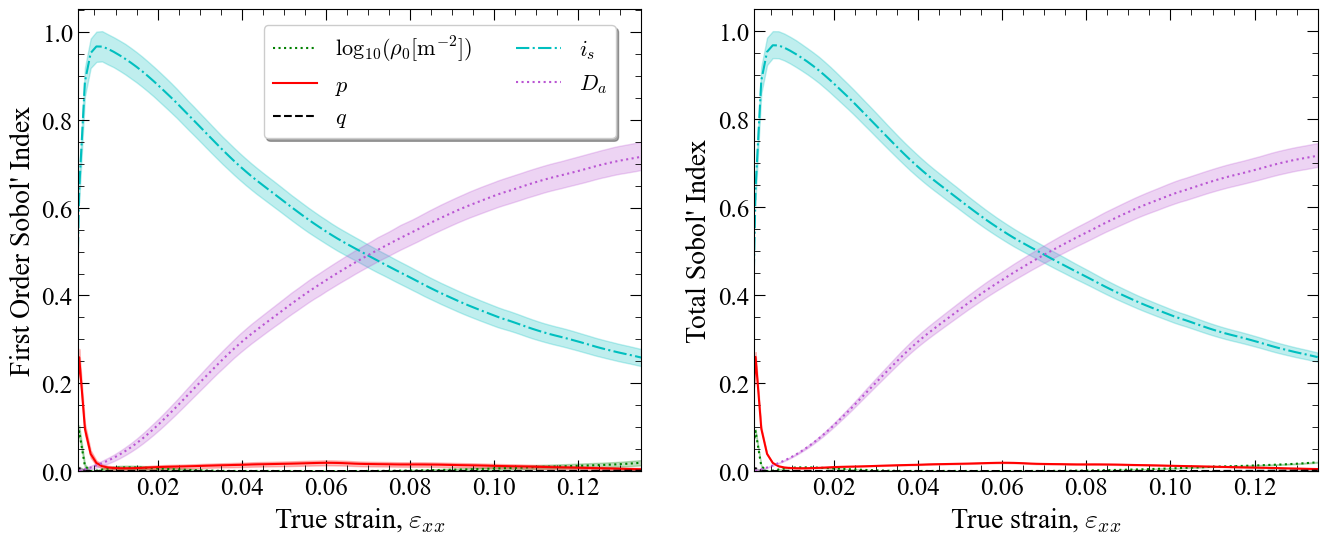

In [193]:
fig_dislo_sobol_111,axs_dislo_sobol_111=plt.subplots(1,2,sharey=False,figsize=(16,6))

for i in range(len(dislo_fitting_param_names)):

    color = next(color_cycler_first)

    axs_dislo_sobol_111[0].fill_between(x=strain_incs,
                    y1=boot_dislo_111_final.first_order.confidence_interval.low[:,i],
                    y2=boot_dislo_111_final.first_order.confidence_interval.high[:,i],
                    alpha=0.25,
                    color = color)
    axs_dislo_sobol_111[1].fill_between(x=strain_incs,
                    y1=boot_dislo_111_final.total_order.confidence_interval.low[:,i],
                    y2=boot_dislo_111_final.total_order.confidence_interval.high[:,i],
                    alpha=0.25,
                    color = color)
    
    axs_dislo_sobol_111[0].plot(strain_incs,local_sobol_dislo_111_final.first_order[:,i], ls = next(SA_linecycler_first), color = color, label=fr'{dislo_fitting_param_names[i]}')
    axs_dislo_sobol_111[1].plot(strain_incs,local_sobol_dislo_111_final.total_order[:,i], ls = next(SA_linecycler_total), color = color, label=fr'{dislo_fitting_param_names[i]}')

L_111_final = axs_dislo_sobol_111[0].legend(loc = (0.33, 0.72), ncol = 2, fontsize = 16, shadow = True)
axs_dislo_sobol_111[0].set_ylabel("First Order Sobol' Index", fontsize=20)
axs_dislo_sobol_111[1].set_ylabel("Total Sobol' Index", fontsize=20)
axs_dislo_sobol_111[0].set_xlabel(r'True strain, $\varepsilon_{xx}$', fontsize=20, math_fontfamily = 'cm')
axs_dislo_sobol_111[1].set_xlabel(r'True strain, $\varepsilon_{xx}$', fontsize=20, math_fontfamily = 'cm')

for text in L_111_final.get_texts():
    text.set_math_fontfamily('cm')


axs_dislo_sobol_111[0].set_xlim(0.001, max(strain_incs))
axs_dislo_sobol_111[1].set_xlim(0.001, max(strain_incs))

#axs_dislo_sobol_111[0].set_xscale('log')
#axs_dislo_sobol_111[1].set_xscale('log')

axs_dislo_sobol_111[0].set_ylim(0)
axs_dislo_sobol_111[1].set_ylim(0)

axs_dislo_sobol_111[0].tick_params(which = 'both', direction = 'in', top = True, right = True, labelsize = 18)
axs_dislo_sobol_111[0].tick_params(which = 'minor', length = 4)
axs_dislo_sobol_111[0].tick_params(which = 'major', length = 8)

axs_dislo_sobol_111[1].tick_params(which = 'both', direction = 'in', top = True, right = True, labelsize = 18)
axs_dislo_sobol_111[1].tick_params(which = 'minor', length = 4)
axs_dislo_sobol_111[1].tick_params(which = 'major', length = 8)

axs_dislo_sobol_111[0].xaxis.set_minor_locator(AutoMinorLocator(4))
axs_dislo_sobol_111[0].yaxis.set_minor_locator(AutoMinorLocator(4))
axs_dislo_sobol_111[1].xaxis.set_minor_locator(AutoMinorLocator(4))
axs_dislo_sobol_111[1].yaxis.set_minor_locator(AutoMinorLocator(4))

#plt.savefig('./plots/sobol_SA/dislotwin_sobol_sensitivity_analysis.png', dpi = 800)

Values for polycrystal simulations

In [93]:
for i in range(len(mean_params)):
    if i == 0:
        print(10**mean_params[i])
    else:
        print(mean_params[i])

256001210.6470488
0.34657203679829707
1.488069010238742
18.656516300871978
5.9800687484319495
